In [55]:
import pandas as pd

In [56]:
nodes = pd.read_pickle("../flatten/processed-data/7-s288c-nodes-final-per-node.pkl")

In [57]:
needed = nodes[["node", "UniProtKB-AC", "L"]]

In [58]:
# Parse Rosetta FastRelax log summaries into a DataFrame
# -----------------------------------------------------
# Configure the input file path here:
LOG_PATH = "../6-Rosetta-scoring/times.txt"   # e.g., "/path/to/your/grepped_log_lines.txt"

import re
import pandas as pd
from pathlib import Path

# Regex:
#  - log_name: everything before the first colon
#  - runtime: integer before " seconds"
line_re = re.compile(
    r'^(?P<log_name>[^:]+):.*?reported success in\s+(?P<runtime>\d+)\s+seconds',
    re.IGNORECASE
)

rows, unmatched = [], []

with open(LOG_PATH, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = line_re.search(line)
        if not m:
            unmatched.append(line)
            continue
        log_name = m.group("log_name")
        runtime = int(m.group("runtime"))
        # node = first token before the replica suffix, i.e., before the first "_"
        # Safe even if node contains '-' characters.
        node = log_name.split("_", 1)[0]
        rows.append({"log_name": log_name, "runtime": runtime, "node": node})

df = pd.DataFrame(rows, columns=["log_name", "runtime", "node"])

print(f"Parsed rows: {len(df)}")
if unmatched:
    print(f"Unmatched lines (first 5 of {len(unmatched)}):")
    for l in unmatched[:5]:
        print("  ", l)

df.head()


Parsed rows: 7769


,log_name,runtime,node
0,Q0140_0001.log,3450,Q0140
1,Q0140_0002.log,2672,Q0140
2,Q0140_0003.log,2808,Q0140
3,Q0140_0004.log,3659,Q0140
4,Q0140_0005.log,3334,Q0140


In [59]:
# If your parsed dataframe is named differently, rename it to df or adjust below.
df_clean = df.dropna(subset=["node", "runtime"]).copy()

# Average runtime per replica for each protein (node), based on available replicas
stats = (
    df_clean.groupby("node", as_index=False)
            .agg(mean_runtime=("runtime", "mean"),
                 reps_observed=("runtime", "size"))
)

# Expected total time for 10 serial replicas on one CPU
stats["expected_runtime"] = (stats["mean_runtime"] * 10).round().astype(int)  # seconds

# Final two-column dataframe
expected_df = stats[["node", "expected_runtime"]].sort_values("node").reset_index(drop=True)

# Peek and (optionally) save
display(expected_df.head(10))
# expected_df.to_csv("expected_runtime_by_protein.csv", index=False)

,node,expected_runtime
0,Q0140,31860
1,YAL010C,60647
2,YAL020C,8977
3,YAL025C,19826
4,YAL035W,131422
5,YAL044W-A,775
6,YAL046C,3256
7,YAL059W,8593
8,YBL008W,20115
9,YBL022C,165220


In [60]:
expected_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821 entries, 0 to 820
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   node              821 non-null    object
 1   expected_runtime  821 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [61]:
df = nodes.merge(expected_df, on="node", how="left")

In [69]:
df = df[~df["L"].isna()]
df.info()
df["expected_runtime"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 3341 entries, 1 to 3926
Columns: 173 entries, node to expected_runtime
dtypes: bool(2), float64(63), int64(39), object(69)
memory usage: 4.4+ MB
<class 'pandas.core.series.Series'>
Index: 3341 entries, 1 to 3926
Series name: expected_runtime
Non-Null Count  Dtype  
--------------  -----  
821 non-null    float64
dtypes: float64(1)
memory usage: 52.2 KB


Text(0.5, 0, 'Protein length, aa')

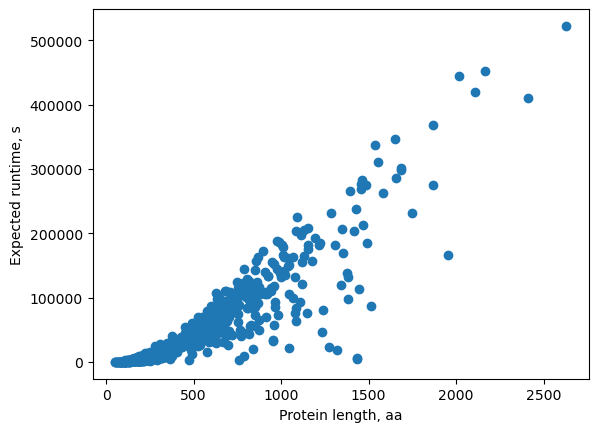

In [68]:
import matplotlib.pyplot as plt
plt.clf()
plt.scatter(df["L"], df["expected_runtime"])
plt.ylabel("Expected runtime, s")
plt.xlabel("Protein length, aa")

In [72]:
train = df[~df["expected_runtime"].isna()]
train.info()

predict_df = df[df["expected_runtime"].isna()]
predict_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, 1 to 1417
Columns: 173 entries, node to expected_runtime
dtypes: bool(2), float64(63), int64(39), object(69)
memory usage: 1.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 2520 entries, 36 to 3926
Columns: 173 entries, node to expected_runtime
dtypes: bool(2), float64(63), int64(39), object(69)
memory usage: 3.3+ MB


In [73]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# -----------------------
# Helper metrics
# -----------------------
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat)**2)))
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))
def r2(y, yhat):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return float(1 - ss_res/ss_tot) if ss_tot > 0 else np.nan
def aic(y, yhat, k):
    n = len(y)
    rss = np.sum((y - yhat)**2)
    return float(n * np.log(rss / n) + 2 * k) if rss > 0 else -np.inf

# -----------------------
# Fit models (L only)
# -----------------------
def fit_length_models(train, L_col="L", y_col="expected_runtime"):
    # Clean training data
    t = (train[[L_col, y_col]]
         .dropna()
         .astype({L_col: float, y_col: float}))
    t = t[(t[L_col] > 0) & (t[y_col] > 0)].reset_index(drop=True)
    if t.empty:
        raise ValueError("No valid training rows with positive L and expected_runtime.")

    L = t[L_col].values.reshape(-1, 1)
    y = t[y_col].values
    logy = np.log(y)
    logL = np.log(t[L_col].values).reshape(-1, 1)

    models, scores = {}, []

    # 1) Linear: y = a + b·L  (k=2)
    lin = LinearRegression().fit(L, y)
    yhat_lin = lin.predict(L)
    models["linear"] = {
        "desc": "y = a + b·L",
        "k": 2,
        "predict": lambda Lnew: lin.predict(np.array(Lnew, dtype=float).reshape(-1,1)),
    }
    scores.append({"model":"linear","R2":r2(y,yhat_lin),"RMSE":rmse(y,yhat_lin),
                   "MAE":mae(y,yhat_lin),"AIC":aic(y,yhat_lin,k=2)})

    # 2) Quadratic: y = a + b·L + c·L²  (k=3)
    Xq = np.hstack([L, L**2])
    quad = LinearRegression().fit(Xq, y)
    yhat_quad = quad.predict(Xq)
    models["quadratic"] = {
        "desc": "y = a + b·L + c·L²",
        "k": 3,
        "predict": lambda Lnew: quad.predict(
            np.hstack([np.array(Lnew, dtype=float).reshape(-1,1),
                       np.array(Lnew, dtype=float).reshape(-1,1)**2])
        ),
    }
    scores.append({"model":"quadratic","R2":r2(y,yhat_quad),"RMSE":rmse(y,yhat_quad),
                   "MAE":mae(y,yhat_quad),"AIC":aic(y,yhat_quad,k=3)})

    # 3) Exponential: y = a·e^{bL}  => log y = log a + b·L  (k=2)
    exp_lr = LinearRegression().fit(L, logy)
    yhat_exp = np.exp(exp_lr.predict(L))
    models["exponential"] = {
        "desc": "y = a·e^{b·L}",
        "k": 2,
        "predict": lambda Lnew: np.exp(exp_lr.predict(np.array(Lnew, dtype=float).reshape(-1,1))),
    }
    scores.append({"model":"exponential","R2":r2(y,yhat_exp),"RMSE":rmse(y,yhat_exp),
                   "MAE":mae(y,yhat_exp),"AIC":aic(y,yhat_exp,k=2)})

    # 4) Power-law: y = a·L^{b}  => log y = log a + b·log L  (k=2)
    pl_lr = LinearRegression().fit(logL, logy)
    yhat_pl = np.exp(pl_lr.predict(logL))
    models["powerlaw"] = {
        "desc": "y = a·L^{b}",
        "k": 2,
        "predict": lambda Lnew: np.exp(pl_lr.predict(np.log(np.array(Lnew, dtype=float).reshape(-1,1)))),
    }
    scores.append({"model":"powerlaw","R2":r2(y,yhat_pl),"RMSE":rmse(y,yhat_pl),
                   "MAE":mae(y,yhat_pl),"AIC":aic(y,yhat_pl,k=2)})

    score_df = (pd.DataFrame(scores)
                  .sort_values(["AIC","RMSE"], ascending=[True, True])
                  .reset_index(drop=True))
    best_model = score_df.loc[0, "model"]
    return models, score_df, best_model

# -----------------------
# Predict on new data
# -----------------------
def add_length_predictions(pred_df, models, model_name, L_col="L",
                           out_col="expected_runtime_pred"):
    if model_name not in models:
        raise ValueError(f"Unknown model '{model_name}'. Available: {list(models.keys())}")
    Lnew = pred_df[L_col].astype(float).values
    yhat = models[model_name]["predict"](Lnew)
    pred_out = pred_df.copy()
    # Guard against tiny negatives from numeric noise
    pred_out[out_col] = np.maximum(yhat, 0.0)
    return pred_out

# =======================
# Run: fit, score, predict
# =======================
models, score_df, best_model = fit_length_models(train, L_col="L", y_col="expected_runtime")
display(score_df)
print("Best by AIC:", best_model, "—", models[best_model]["desc"])

# If you already have a prediction dataframe named 'predict_df' (expected_runtime is NaN):
try:
    predict_df
except NameError:
    # Fall back: derive from a larger df if present, else raise
    try:
        predict_df = df[df["expected_runtime"].isna()].copy()
    except Exception as e:
        raise ValueError("Please define 'predict_df' with column 'L' and expected_runtime=NaN.") from e

predicted = add_length_predictions(predict_df, models, best_model, L_col="L",
                                   out_col="expected_runtime_pred")

# Preview and (optionally) save
display(predicted.head(10))
# predicted.to_csv("predicted_expected_runtime.csv", index=False)


,model,R2,RMSE,MAE,AIC
0,quadratic,0.841341,2.594736e+04,13493.890605,16695.000888
1,linear,0.817706,2.781294e+04,15769.195936,16807.007640
2,powerlaw,0.493951,4.634015e+04,17799.597339,17645.260453
3,exponential,-398.614158,1.302212e+06,116586.644186,23122.662248


Best by AIC: quadratic — y = a + b·L + c·L²


,node,_wkshell,degree_centrality,betweenness_centrality,eigenvector_centrality,closeness_centrality,load_centrality,pagerank,information_centrality,CentralityCosDist_rank,...,Y2H_CentralityCosDist_rank,Y2H_CentralityCosDist_similarity_score,meltome-id,meltome-melting-point,meltome-stability-class,meltome-AUC,meltome-fit-converged,meltome-fit-R2,expected_runtime,expected_runtime_pred
36,YNL059C,383,0.006623,0.006354,0.000498,0.290513,0.006565,0.000438,0.000591,2397.0,...,NaN,NaN,P53946_ARP5,43.02,non-stable,0.30,True,0.99,NaN,79644.872968
37,YBL024W,21,0.000509,0.000100,0.000038,0.213059,0.000117,0.000087,0.000256,459.0,...,NaN,NaN,P38205_NCL1,50.85,medium,0.54,True,0.99,NaN,68736.567417
38,YDR356W,488,0.010188,0.004312,0.000802,0.292232,0.004262,0.000627,0.000612,2640.0,...,NaN,NaN,P32380_SPC110,49.23,medium,0.57,True,0.98,NaN,110758.282336
69,YNL247W,178,0.002802,0.000909,0.000264,0.253717,0.000931,0.000241,0.000520,1955.0,...,NaN,NaN,P53852_YNL247W,51.35,medium,0.55,True,0.99,NaN,81530.603993
70,YLR244C,349,0.004330,0.001404,0.004688,0.273827,0.001419,0.000322,0.000560,2366.0,...,968.0,0.973794,Q01662_MAP1,41.41,non-stable,0.19,True,1.00,NaN,27723.010175
71,YOL111C,181,0.002292,0.000466,0.000877,0.252760,0.000442,0.000194,0.000491,1972.0,...,798.0,0.973824,Q12285_MDY2,53.11,medium,0.64,True,0.95,NaN,7046.021428
90,YDR144C,204,0.003821,0.001124,0.000075,0.264149,0.001155,0.000315,0.000550,2016.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52677.428277
91,YDR245W,318,0.005604,0.000642,0.000026,0.249102,0.000573,0.000372,0.000575,2369.0,...,867.5,0.973811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28477.811098
93,YGL105W,297,0.003311,0.000170,0.002965,0.260807,0.000152,0.000197,0.000544,2275.0,...,NaN,NaN,P46672_ARC1,45.17,medium,0.37,True,1.00,NaN,26347.107872
94,YFR024C-A,274,0.003566,0.000560,0.000565,0.257655,0.000535,0.000254,0.000549,2235.0,...,830.0,0.973819,P43603_LSB3,48.80,medium,0.52,True,0.99,NaN,36981.358652


In [76]:
print (sum(predicted["expected_runtime_pred"])/3600./96)

392.60202558530614


In [77]:
predicted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2520 entries, 36 to 3926
Columns: 174 entries, node to expected_runtime_pred
dtypes: bool(2), float64(64), int64(39), object(69)
memory usage: 3.3+ MB
